### **Web Scraping using Selenium**

#### **Extract the Data**


In [1]:
#import packages
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

import json
from time import sleep

#launch Selenium
driver = webdriver.Chrome()
driver.get(f'https://www.zeptonow.com/search?query={'product'}') #write your own thing for query
sleep(2)

#select location
location_button = driver.find_element(By.XPATH,'//button[@aria-label="Select Location"]')
location_button.click()
sleep(3)
location_input = driver.find_element(By.XPATH,"//input[@placeholder='Search a new address']")
location_input.send_keys("500003") # select your pincode
sleep(4)
location_item = driver.find_element(By.XPATH,"//div[@data-testid='address-search-item']")
location_item.click()
confirm_button = WebDriverWait(driver,10).until(EC.presence_of_element_located((By.XPATH,'//button[contains(@aria-label,"Confirm")]')))
confirm_button.click()
sleep(4)

for _ in range(10):
    driver.find_element(By.TAG_NAME, 'body').send_keys(Keys.END)
    sleep(2)

# Extract all product cards that contain 'ADD' button
products = driver.find_elements(By.XPATH, "//a[descendant::*[contains(text(),'ADD')]]")

import re

product_details = []

for item in products:
    try:
        details = item.text.split('\n')

        data = {
            "Name": None,
            "Original Price": None,
            "Discounted Price": None,
            "Discount Percent": None,
            "Price (raw)": None,   # keep original raw price string if needed
            "Premium": "No",
            "quantity": None,
            "Rating": None,
            "Review Count": None,
            "Delivery Time": None,
            "Category": "product name"
            
        }

        # Premium -> Yes / No
        if "Premium" in details:
            data["Premium"] = "Yes"


        # PRICE parsing: find all rupee amounts (e.g. ₹52, ₹1,299)
                #  PRICE parsing — Extract all ₹ amounts and keep only the highest value
        price_strs = []
        for v in details:
            found = re.findall(r'₹\s*[\d,]+', v)  # find ₹52, ₹1,299 etc.
            if found:
                price_strs.extend(found)

        price_nums = []
        for p in price_strs:
            num = re.sub(r'[^\d]', '', p)  # remove ₹ and commas
            if num.isdigit():
                price_nums.append(int(num))

        #  Store only highest price as "Price"
        if price_nums:
            data["Price"] = max(price_nums)
        else:
            data["Price"] = None


        if price_nums:
            # assume highest is original price, lowest is discounted (common case)
            original = max(price_nums)
            discounted = min(price_nums)
            data["Original Price"] = original
            data["Discounted Price"] = discounted
            data["Price (raw)"] = " | ".join(price_strs)
            # compute percent only if there's a real discount
            if original and discounted and original > discounted:
                disc_pct = round((original - discounted) / original * 100, 2)
                data["Discount Percent"] = disc_pct
        else:
            data["Price (raw)"] = None

        # Product Name: choose the longest text line that is not a price/discount/rating token
        candidates = []
        for v in details:
            if '₹' in v or 'SAVE' in v or '%' in v or re.match(r'^\d+(\.\d+)?$', v):
                continue
            # ignore very short tokens like 'ADD' or 'OFF'
            if len(v.strip()) < 3:
                continue
            candidates.append(v.strip())
        if candidates:
            data["Name"] = max(candidates, key=len)

        # quantity
        amt = [v for v in details if re.search(r'\b(pack|g|kg|ml|ltr|combo|x\s*\d+)\b', v, re.IGNORECASE)]
        data["quantity"] = amt[0] if amt else None

        # Rating 
        rating_vals = [v for v in details if re.match(r'^\d+\.\d+$', v.strip())]
        data["Rating"] = float(rating_vals[0]) if rating_vals else None

        # Review Count: first try parentheses like (123), then '123 ratings', else largest integer-like token
        review_count = None
        # 1) parentheses
        for v in details:
            m = re.search(r'\((\d[\d,]*)\)', v)
            if m:
                review_count = int(m.group(1).replace(',', ''))
                break
        # 2) words 'rating' or 'ratings' or 'reviews'
        if review_count is None:
            for v in details:
                if re.search(r'\b(rating|ratings|reviews)\b', v, re.IGNORECASE):
                    nums = re.findall(r'(\d[\d,]*)', v)
                    if nums:
                        review_count = int(nums[0].replace(',', ''))
                        break
        # 3) fallback: any integer-like tokens in details (exclude decimal ratings)
        if review_count is None:
            int_tokens = []
            for v in details:
                # skip decimal tokens (these are likely ratings)
                if re.match(r'^\d+\.\d+$', v.strip()):
                    continue
                nums = re.findall(r'(\d[\d,]*)', v)
                for n in nums:
                    int_tokens.append(int(n.replace(',', '')))
            if int_tokens:
                review_count = max(int_tokens)  # pick largest plausible count
        data["Review Count"] = review_count

        # Delivery Time: look for 'min' or phrases like '30 mins' or last numeric larger than 24 maybe (fallback)
        delivery = None
        for v in details[::-1]:  # search from bottom up
            if re.search(r'\bmin\b|\bmins\b|\bminute\b', v, re.IGNORECASE):
                delivery = v
                break
        if delivery is None:
            # fallback: last standalone integer token that is not review or rating (conservative)
            for v in details[::-1]:
                if re.match(r'^\d+$', v.strip()):
                    maybe = int(v.strip())
                    # consider plausible delivery numeric less than, say, 600 (minutes)
                    if 0 < maybe < 600:
                        delivery = v
                        break
        data["Delivery Time"] = delivery

        product_details.append(data)

    except Exception as e:
        print("Error parsing product:", e)

# Convert to DataFrame
import pandas as pd

try:
    df = pd.DataFrame(product_details)

    # Remove duplicates and empty rows if any
    df.drop_duplicates(inplace=True)
    df = df.dropna(how='all')

    # Save as CSV
    df.to_csv('zepto_product.csv', index=False, encoding='utf-8')


    print("Data saved successfully as zepto_products.csv and zepto_products.json")
except Exception as e:
    print("Error saving files:", e)


Data saved successfully as zepto_products.csv and zepto_products.json


In [2]:
# sample preview of dataset
df

,Name,Original Price,Discounted Price,Discount Percent,Price (raw),Premium,quantity,Rating,Review Count,Delivery Time,Category,Price
0,Campa Orange Soft Drink,19,1,94.74,₹19 | ₹1,No,1 pc (500 ml),4.7,500,9 mins,cool drinks,19
1,3 Sisters - Super Cola | Powered by Dates,90,14,84.44,₹76 | ₹90 | ₹14,No,1 pc (250 ml),4.7,118,9 mins,cool drinks,90
2,Thums Up Soft Drink,45,9,80.00,₹36 | ₹45 | ₹9,No,1 pc (750 ml),4.7,750,9 mins,cool drinks,45
3,Sprite Lemon and Lime Soft Drink,70,11,84.29,₹59 | ₹70 | ₹11,No,None,4.6,70,9 mins,cool drinks,70
4,Thums Up Soft Drink,70,12,82.86,₹58 | ₹70 | ₹12,No,None,4.7,465,9 mins,cool drinks,70
...,...,...,...,...,...,...,...,...,...,...,...,...
258,Fast&Up Reload Low Sugar Energy Drink - Tasty ...,180,90,50.00,₹90 | ₹180 | ₹90,No,Fast&Up Reload Low Sugar Energy Drink - Tasty ...,4.6,552,9 mins,cool drinks,180
259,Coolberg Non Alcoholic Beer | Party Pack,594,16,97.31,₹578 | ₹594 | ₹16,No,Coolberg Non Alcoholic Beer | Party Pack,4.3,189,9 mins,cool drinks,594
260,Prime Hydration Ice Orange Flavoured Drink,399,43,89.22,₹356 | ₹399 | ₹43,No,1 pc (500 ml),4.5,544,9 mins,cool drinks,399
261,Fast&Up Reload Ready To Drink ~ Low Sugar Ener...,180,55,69.44,₹125 | ₹180 | ₹55,No,Fast&Up Reload Ready To Drink ~ Low Sugar Ener...,4.6,184,9 mins,cool drinks,180


In [ ]:
# basic dataset cleaning 
df.drop(['Price (raw)','Price'], axis=1, inplace=True)
df['Name'] = df['Name'].astype(str).str.replace(r'[/\-&(|].*', '', regex=True).str.strip()
import re
def extract_quantity(qty):
    qty = str(qty).strip()

    match = re.search(r'\b(\d+)\s*(g|kg|ml|l|ltr|pcs)\b', qty, re.IGNORECASE)
    if match:
        return match.group(1) + " " + match.group(2).lower()

    
    return None  # or return qty if you want to keep the text

# Apply to DataFrame column
df['quantity'] = df['quantity'].apply(extract_quantity)
df.to_csv('zepto_babycare.csv', index=False, encoding='utf-8')

### **Export into .csv format**

In [10]:
import pandas as pd
import os
folder_path = r"D:\innomatics_247B\python\anakonda\python_427B\zepto_DA"  # change this

#  Empty list to collect all DataFrames
dataframes = []

#  Loop through all CSV or Excel files in the folder
for file in os.listdir(folder_path):
    if file.endswith(".csv") or file.endswith(".xlsx"):
        file_path = os.path.join(folder_path, file)
        print(f"Reading: {file}")

        # Read Excel or CSV automatically
        if file.endswith(".csv"):
            df = pd.read_csv(file_path)
        else:
            df = pd.read_excel(file_path)

        dataframes.append(df)

#  Merge all into one DataFrame
final_df = pd.concat(dataframes, ignore_index=True)

#  Remove duplicates if any
final_df.drop_duplicates(inplace=True)

#  Export as one file
final_df.to_csv("zepto_products.csv", index=False, encoding='utf-8')

print(" All files merged successfully into zepto_products.csv")


Reading: zepto_books.csv
Reading: zepto_bread.csv
Reading: zepto_cheese.csv
Reading: zepto_chips.csv
Reading: zepto_Chocolate.csv
Reading: zepto_cookies.csv
Reading: zepto_cooldrinks.csv
Reading: zepto_detergent .csv
Reading: zepto_earbuds.csv
Reading: zepto_fruits.csv
Reading: zepto_Ice cream.csv
Reading: zepto_jewellery.csv
Reading: zepto_meats.csv
Reading: zepto_milk.csv
Reading: zepto_perfume.csv
Reading: zepto_products.csv
Reading: zepto_skincare.csv
Reading: zepto_speakers.csv
Reading: zepto_toys.csv
Reading: zepto_vegetables.csv
 All files merged successfully into zepto_products.csv


### **Importing Libraries**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### **Loading the data**

In [14]:
df = pd.read_csv(r"D:\innomatics_247B\python\anakonda\inno_427B\projects_DA\zepto_DA\zepto_products.csv")

### **Preview Of The Dataset**

In [15]:
df.columns = df.columns.str.lower().str.replace(" ","_")
df = df.rename(columns = {'name':'product_name'})
df

,product_name,original_price,discounted_price,discount_percent,premium,quantity,rating,review_count,delivery_time,category,selling_price
0,My First Activity Book Word Search,129,1,96.55,No,1 pcs,4.5,67,22 mins,books,128
1,2000+ Reward Stickers Book,220,94,57.27,No,2 pcs,4.9,78,22 mins,books,126
2,My First Book Of Writing Numbers,60,11,81.67,No,1 pcs,4.5,945,22 mins,books,49
3,The Adventures of Sherlock Holmes,499,216,56.71,No,2 pcs,4.4,170,22 mins,books,283
4,Science Books For Kids,180,61,66.11,No,1 pcs,NaN,71,22 mins,books,119
...,...,...,...,...,...,...,...,...,...,...,...
2557,Lollo Green Lettuce Hydroponically Grown,48,11,77.08,No,200 g,NaN,150,8 mins,vegetables,37
2558,Banana Leaves,54,14,74.07,No,200 g,NaN,54,8 mins,vegetables,40
2559,Zucchini Green,58,13,77.59,No,200 g,NaN,250,8 mins,vegetables,45
2560,Super Sweet Corn Cob Combo,122,30,75.41,No,200 g,NaN,122,8 mins,vegetables,92


### **Understanding The Structure Of The Dataset**

In [16]:
df.shape

(2562, 11)

### **Observation:**
#### -> The dataset contains 2562 rows and 11 columns.

### **Pre-viewing the first few rows**

In [17]:
df.head()

,product_name,original_price,discounted_price,discount_percent,premium,quantity,rating,review_count,delivery_time,category,selling_price
0,My First Activity Book Word Search,129,1,96.55,No,1 pcs,4.5,67,22 mins,books,128
1,2000+ Reward Stickers Book,220,94,57.27,No,2 pcs,4.9,78,22 mins,books,126
2,My First Book Of Writing Numbers,60,11,81.67,No,1 pcs,4.5,945,22 mins,books,49
3,The Adventures of Sherlock Holmes,499,216,56.71,No,2 pcs,4.4,170,22 mins,books,283
4,Science Books For Kids,180,61,66.11,No,1 pcs,NaN,71,22 mins,books,119


### **Observation:**
#### **-> The preview shows the first few rows of the data and helps us check if the file loaded correctly.**

### **Dataset structure and its data types**

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2562 entries, 0 to 2561
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_name      2562 non-null   object 
 1   original_price    2562 non-null   int64  
 2   discounted_price  2562 non-null   int64  
 3   discount_percent  2509 non-null   float64
 4   premium           2562 non-null   object 
 5   quantity          2561 non-null   object 
 6   rating            2171 non-null   float64
 7   review_count      2562 non-null   int64  
 8   delivery_time     2562 non-null   object 
 9   category          2562 non-null   object 
 10  selling_price     2562 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 220.3+ KB


### **Statistical Overview of Numerical Data**

In [19]:
df.describe()

,original_price,discounted_price,discount_percent,rating,review_count,selling_price
count,2562.000000,2562.000000,2509.000000,2171.000000,2562.000000,2562.000000
mean,403.283372,91.497268,75.968808,4.444311,383.332943,308.960187
std,591.574458,137.725157,12.823665,0.369841,336.573166,526.384674
min,9.000000,1.000000,50.000000,1.100000,20.000000,8.000000
25%,90.000000,14.000000,66.190000,4.300000,134.000000,68.000000
50%,193.500000,36.000000,77.380000,4.500000,285.500000,139.000000
75%,459.500000,100.000000,85.040000,4.700000,563.750000,335.750000
max,10750.000000,932.000000,99.970000,4.900000,4700.000000,10747.000000


### **value_counts for each column**

In [20]:
df["original_price"].value_counts()

original_price
60     63
40     58
120    52
80     50
100    48
       ..
702     1
23      1
194     1
274     1
183     1
Name: count, Length: 501, dtype: int64

In [21]:
df['discounted_price'].value_counts()

discounted_price
1      104
12      63
14      62
6       56
10      55
      ... 
309      1
779      1
241      1
401      1
282      1
Name: count, Length: 400, dtype: int64

In [22]:
df['discount_percent'].value_counts()

discount_percent
80.00    78
85.00    39
90.00    31
99.95    28
77.50    28
         ..
66.50     1
61.14     1
64.91     1
57.53     1
64.55     1
Name: count, Length: 1101, dtype: int64

In [23]:
df['selling_price'].value_counts()

selling_price
100     48
48      29
32      27
51      22
66      21
        ..
3097     1
481      1
381      1
479      1
982      1
Name: count, Length: 688, dtype: int64

In [24]:
df['rating'].value_counts()

rating
4.7    442
4.6    378
4.5    309
4.4    256
4.2    225
4.3    221
4.8    125
4.9     46
4.1     40
3.9     23
3.7     15
3.8     15
3.6     13
3.4     10
3.1      8
3.3      8
3.2      6
3.5      6
2.6      5
2.9      4
2.2      3
1.1      2
2.8      2
1.8      2
2.7      1
2.1      1
2.4      1
1.2      1
1.7      1
1.4      1
2.3      1
Name: count, dtype: int64

In [50]:
df['category'].value_counts()

category
skin care     242
chocolate     216
cool drink    207
fragrances    199
chips         168
cookies       167
vegetables    162
milk          159
detergent     158
fruits        141
books         131
toys          131
ice cream     129
jewellery     123
Bread          89
meats          82
cheese         58
Name: count, dtype: int64

In [25]:
df['premium'].value_counts()

premium
No     2530
Yes      32
Name: count, dtype: int64

In [26]:
df['quantity'].value_counts()

quantity
1 pcs     230
250 g     180
100 g     179
100 ml    161
200 ml    110
         ... 
49 g        1
601 ml      1
354 ml      1
210 ml      1
24 g        1
Name: count, Length: 190, dtype: int64

In [27]:
df['delivery_time'].value_counts()

delivery_time
5 mins     637
8 mins     446
12 mins    307
9 mins     278
22 mins    259
10 mins    252
6 mins     149
7 mins     142
39 mins     58
20 mins     19
21 mins     14
11 mins      1
Name: count, dtype: int64

In [28]:
df['review_count'].value_counts()

review_count
500    112
250     83
200     74
100     65
400     31
      ... 
698      1
518      1
265      1
693      1
825      1
Name: count, Length: 812, dtype: int64

### **Data Cleaning**

In [29]:
df['delivery_time'] = df['delivery_time'].str.replace('mins' ,' ')
df['delivery_time'] = df['delivery_time'].astype(int)

In [30]:
df.dtypes

product_name         object
original_price        int64
discounted_price      int64
discount_percent    float64
premium              object
quantity             object
rating              float64
review_count          int64
delivery_time         int64
category             object
selling_price         int64
dtype: object

In [31]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print("categorical columns:",categorical_cols)
print("numerical columns:",numerical_cols)

categorical columns: ['product_name', 'premium', 'quantity', 'category']
numerical columns: ['original_price', 'discounted_price', 'discount_percent', 'rating', 'review_count', 'delivery_time', 'selling_price']


### **Observation:**
#### **-> The dataset contains 2562 records and 11 columns**.
#### **-> Out of the 11 columns: -> 4 are categorical (object type), such as:**
#### **-> 'product_name', 'premium', 'quantity', 'category''**
#### **-> 7 are numerical (int64 and float64), including:**
#### **-> **'original_price(₹)', 'discounted_price(₹)', 'discount_percent(%)', 'rating', 'review_count', 'selling_price(₹)','delivery_time'**


 #### **Null values**

In [32]:
df.isnull().sum()

product_name          0
original_price        0
discounted_price      0
discount_percent     53
premium               0
quantity              1
rating              391
review_count          0
delivery_time         0
category              0
selling_price         0
dtype: int64

In [33]:
df['discount_percent'] = df['discount_percent'].fillna(df['discount_percent'].median()).astype(int)
df['discount_percent']

0       96
1       57
2       81
3       56
4       66
        ..
2557    77
2558    74
2559    77
2560    75
2561    75
Name: discount_percent, Length: 2562, dtype: int64

In [34]:
df['rating'] = df['rating'].fillna(df['rating'].median())
df['rating']

0       4.5
1       4.9
2       4.5
3       4.4
4       4.5
       ... 
2557    4.5
2558    4.5
2559    4.5
2560    4.5
2561    4.5
Name: rating, Length: 2562, dtype: float64

In [35]:
df['quantity'] = df['quantity'].fillna(method = 'ffill')
df['quantity']

0       1 pcs
1       2 pcs
2       1 pcs
3       2 pcs
4       1 pcs
        ...  
2557    200 g
2558    200 g
2559    200 g
2560    200 g
2561    200 g
Name: quantity, Length: 2562, dtype: object

In [36]:
df.isnull().sum()

product_name        0
original_price      0
discounted_price    0
discount_percent    0
premium             0
quantity            0
rating              0
review_count        0
delivery_time       0
category            0
selling_price       0
dtype: int64

In [37]:
# skewness of selling price before capping outliers 
df['selling_price'].skew()

np.float64(6.88593275818556)

In [38]:
new_df = df.copy()

In [39]:
#calculating Q1, Q3 and IQR
q1 = new_df['selling_price'].quantile(0.25)
q3 = new_df['selling_price'].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr


In [40]:
# finding outliers
outliers = new_df[(new_df['selling_price'] < lower_limit) | (new_df['selling_price'] > upper_limit)]
len(outliers)

232

In [41]:
# capping the outliers 
new_df['Selling_price'] = new_df['selling_price'].clip(lower=lower_limit, upper=upper_limit)


In [42]:
# moderately skewed
new_df['Selling_price'].skew()

np.float64(1.1568916154918234)

### **Data  Visualization**

### **Univariate Analysis**

### **Numerical Columns**

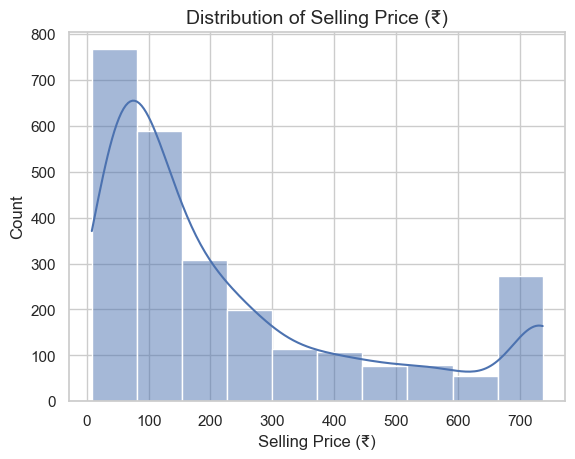

In [33]:
sns.set(style="whitegrid")
sns.histplot(data = new_df['Selling_price'],bins = 10, kde = True)
plt.title('Distribution of Selling Price (₹)', fontsize=14)
plt.xlabel('Selling Price (₹)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.savefig("Distribution of Selling Price (₹)")
plt.show()


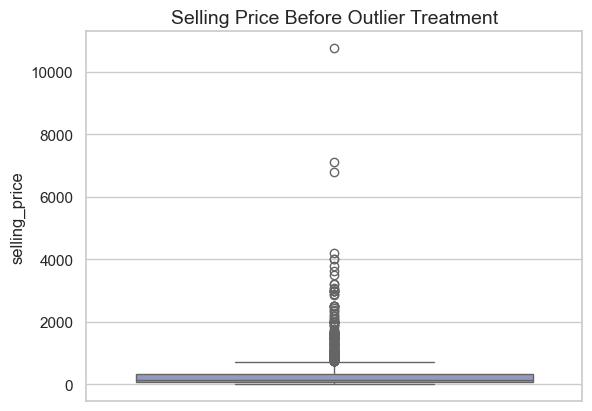

In [34]:
# before handling outliers and capping outliers
sns.set(style="whitegrid")
sns.boxplot(df['selling_price'],palette='BuPu')
plt.title('Selling Price Before Outlier Treatment',fontsize=14)
plt.savefig("Selling Price Before Outlier Treatment")
plt.show()

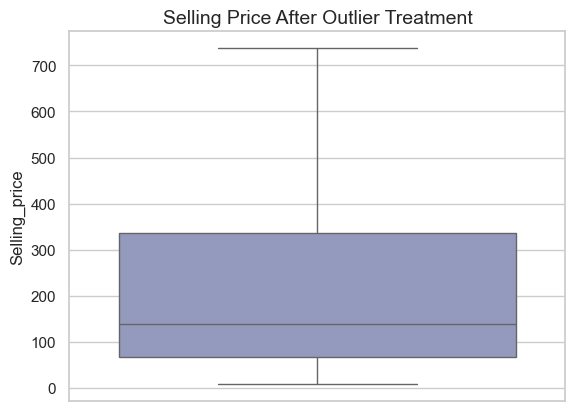

In [35]:
# after handling outliers and capping outliers
sns.set(style="whitegrid")
sns.boxplot(new_df['Selling_price'],palette='BuPu')
plt.title('Selling Price After Outlier Treatment',fontsize=14)
plt.savefig("'Selling Price After Outlier Treatment")
plt.show()

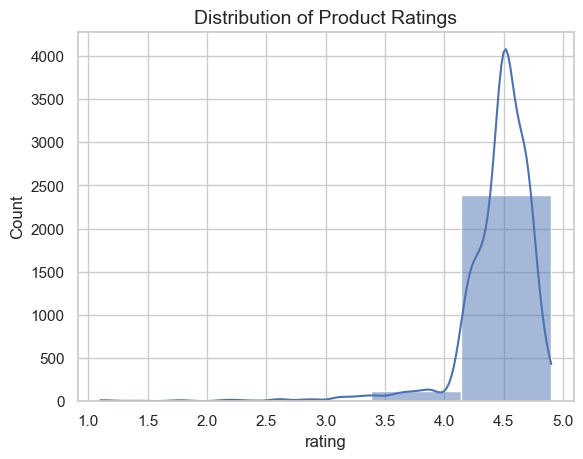

In [36]:
sns.set(style="whitegrid")
sns.histplot(data = df['rating'],bins = 5, kde = True)
plt.title("Distribution of Product Ratings", fontsize=14)
plt.show()

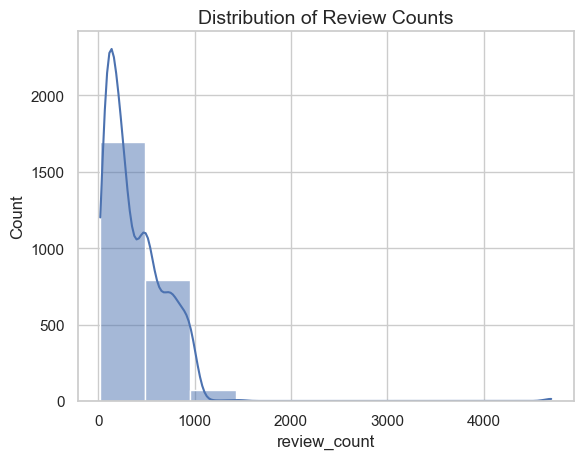

In [37]:
sns.set(style="whitegrid")
sns.histplot(df['review_count'],bins = 10,kde = True,palette='BuPu')
plt.title("Distribution of Review Counts", fontsize=14)
plt.show()

### **Categorical columns**

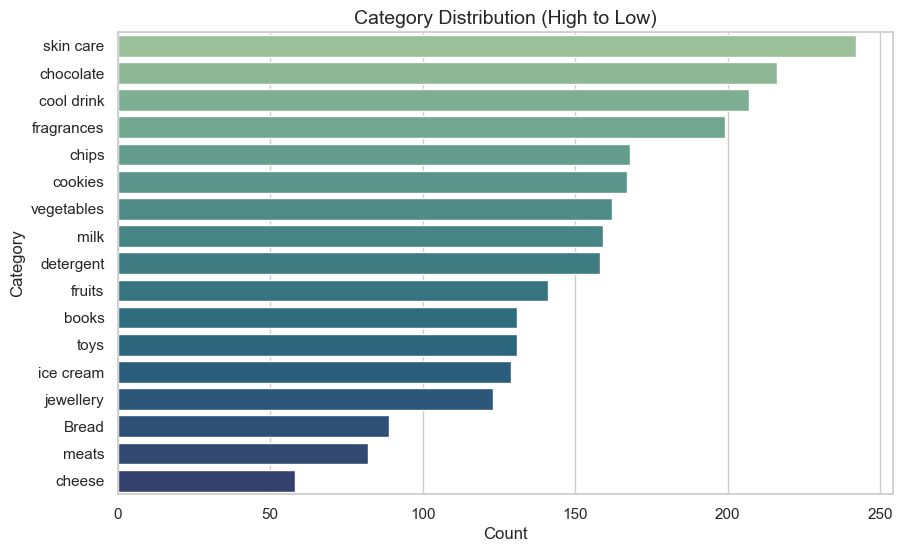

In [38]:
category_counts = df['category'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=category_counts.values, y=category_counts.index, palette='crest')
plt.title("Category Distribution (High to Low)", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.savefig("Category Distribution (High to Low)")
plt.show()

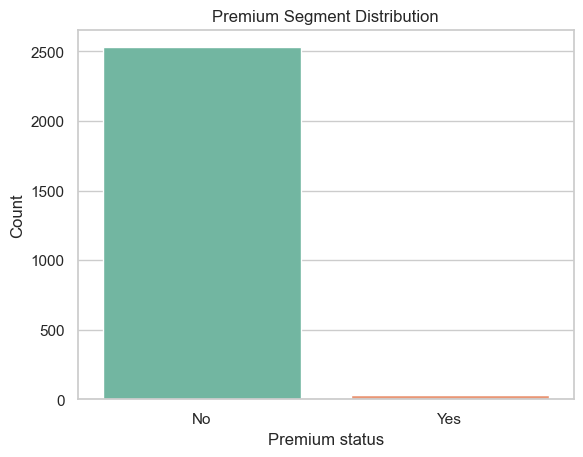

In [39]:
sns.set(style="whitegrid")
premium_counts = df['premium'].value_counts().reset_index()
premium_counts.columns = ['premium', 'count']
sns.barplot(data=premium_counts, x='premium', y='count', palette='Set2')
plt.title('Premium Segment Distribution')
plt.xlabel('Premium status')
plt.ylabel('Count')
plt.show()

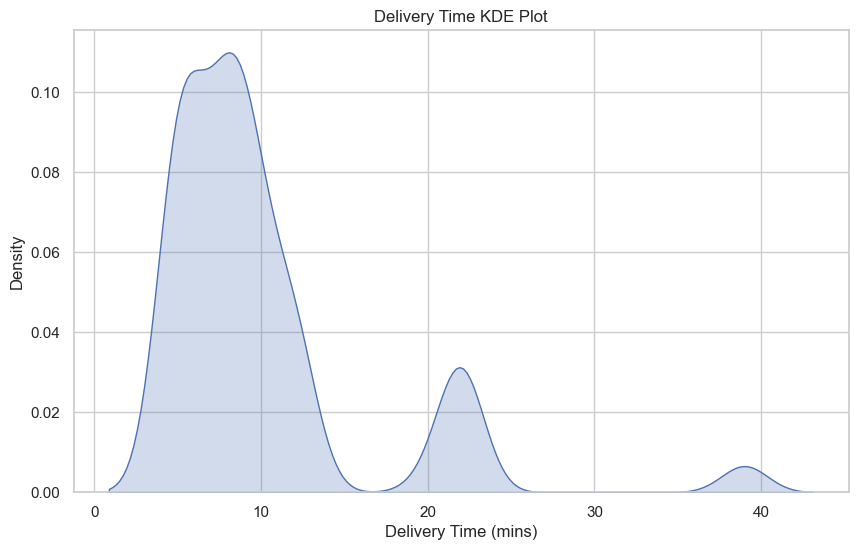

In [42]:
plt.figure(figsize=(10,6))
sns.kdeplot(new_df['delivery_time'], shade=True)
plt.title("Delivery Time KDE Plot")
plt.xlabel("Delivery Time (mins)")
plt.ylabel("Density")
plt.show()

### **Bivariate Analysis**

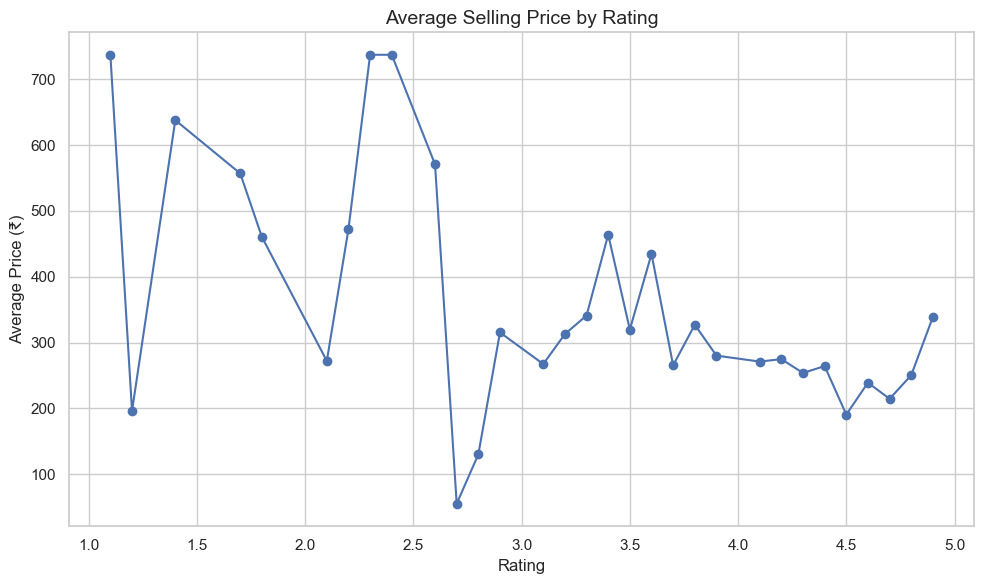

In [43]:
avg_price = new_df.groupby('rating')['Selling_price'].mean().reset_index()
plt.figure(figsize=(10,6))
plt.plot(avg_price['rating'], avg_price['Selling_price'], marker='o')
plt.title("Average Selling Price by Rating", fontsize=14)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Average Price (₹)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("Average Selling Price by Rating")
plt.show()

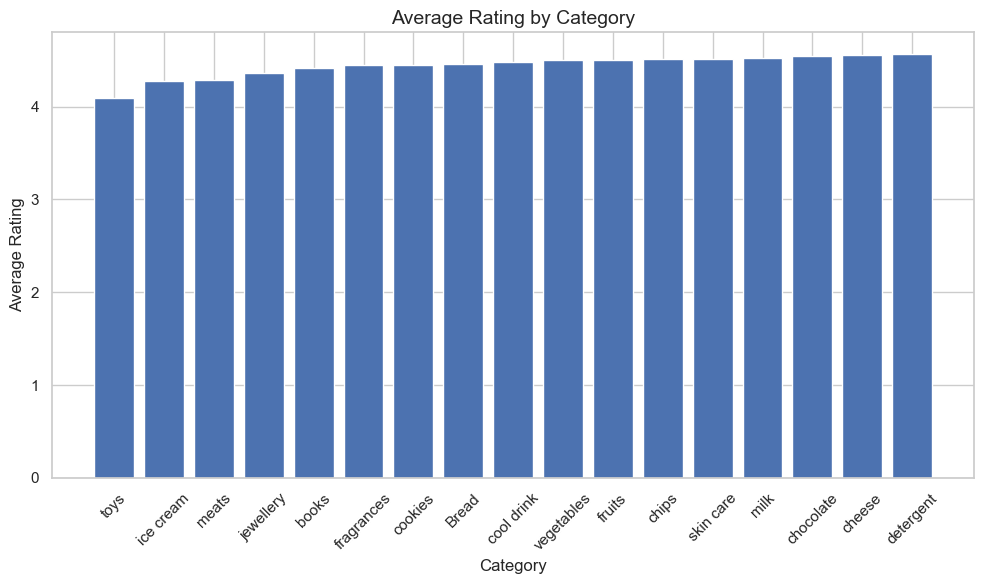

In [44]:
avg_rating = df.groupby('category')['rating'].mean().sort_values()
plt.figure(figsize=(10,6))
plt.bar(avg_rating.index, avg_rating.values)
plt.title("Average Rating by Category", fontsize=14)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


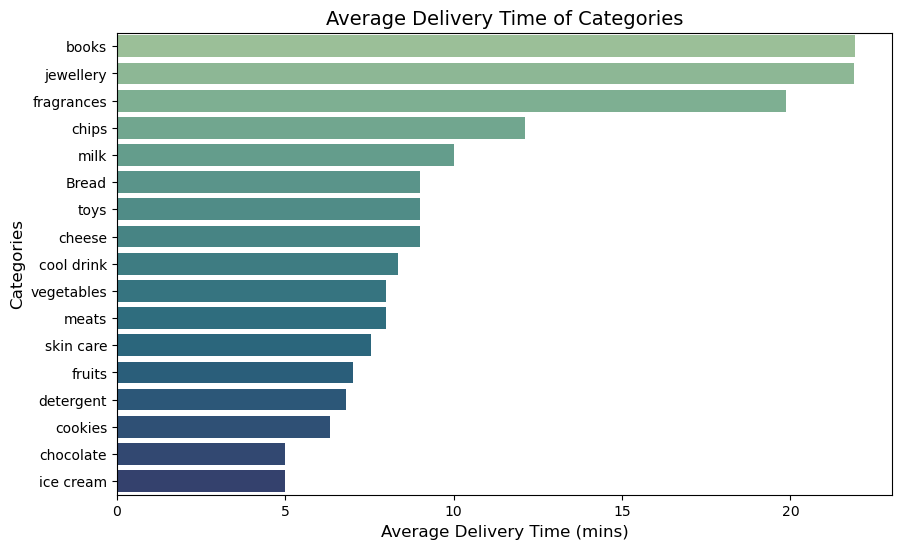

In [43]:
top_categoryitems = df['category'].value_counts()

# Average delivery time for those top categories
avg_delivery_time = (
    df[df['category'].isin(top_categoryitems.index)]
    .groupby('category')['delivery_time']
    .mean()
    .reset_index()
    .sort_values('delivery_time', ascending=False)
)
plt.figure(figsize=(10,6))
sns.barplot(data=avg_delivery_time, x='delivery_time', y='category', palette='crest')
plt.title("Average Delivery Time of Categories", fontsize=14)
plt.xlabel("Average Delivery Time (mins)", fontsize=12)
plt.ylabel("Categories", fontsize=12)
plt.show()

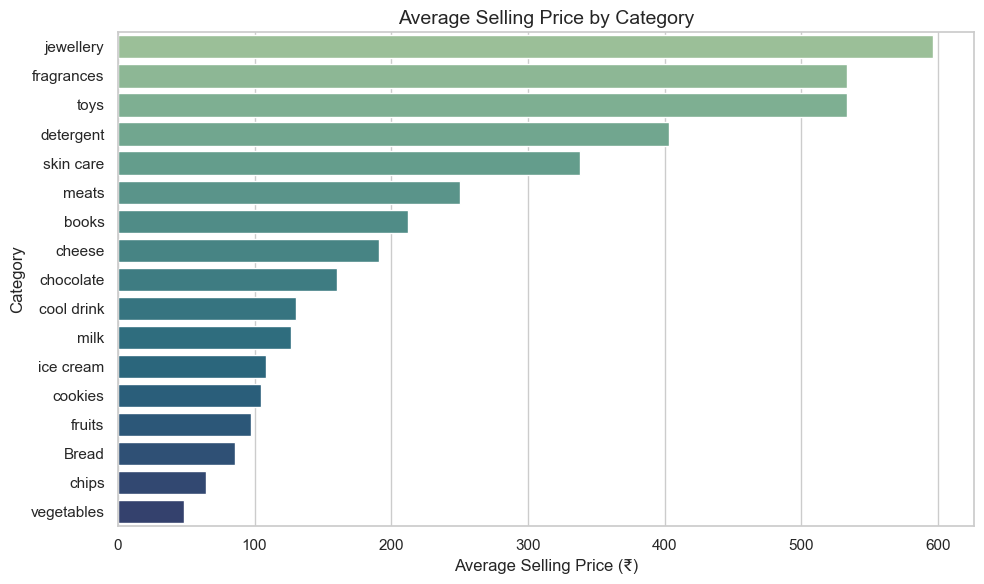

In [35]:
avg_price = new_df.groupby('category')['Selling_price'].mean().reset_index()
avg_price = avg_price.sort_values('Selling_price', ascending=False)
plt.figure(figsize=(10,6))
sns. barplot(
    data=avg_price,
    x='Selling_price',
    y='category',
    palette='crest'
)
plt.title("Average Selling Price by Category", fontsize=14)
plt.xlabel("Average Selling Price (₹)", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.tight_layout()
plt.savefig("Average Selling Price by Category")
plt.show()


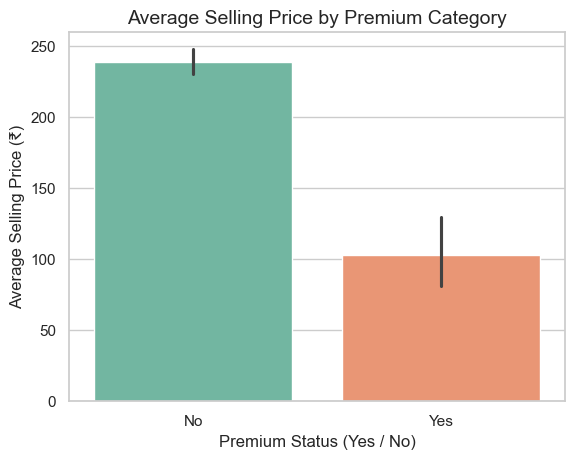

In [36]:
sns.set(style="whitegrid")
sns.barplot(data=new_df, x='premium', y='Selling_price', palette='Set2')
plt.title("Average Selling Price by Premium Category", fontsize=14)
plt.xlabel("Premium Status (Yes / No)", fontsize=12)
plt.ylabel("Average Selling Price (₹)", fontsize=12)
plt.savefig("Average Selling Price by Premium Category")
plt.show()

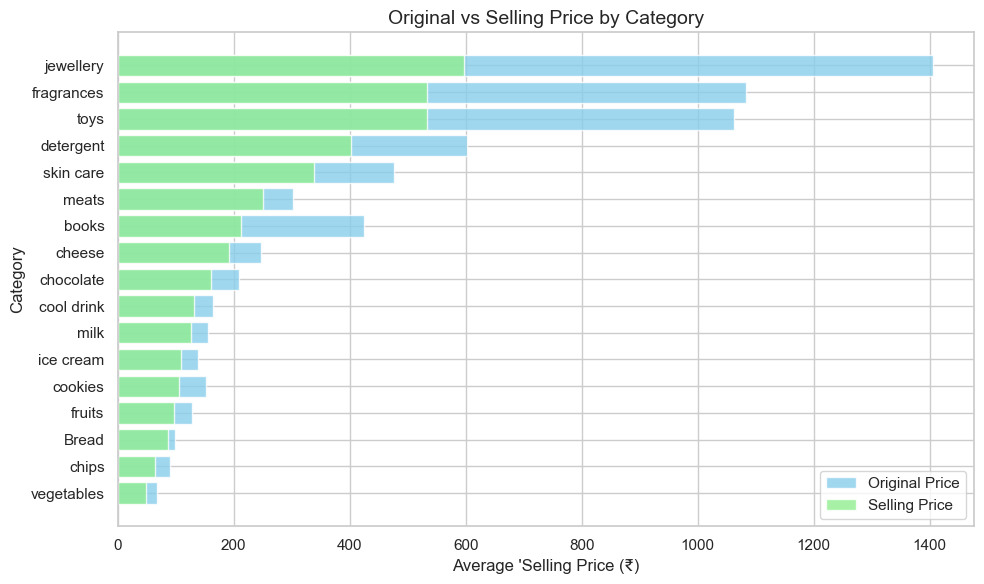

In [52]:
price_compare = new_df.groupby('category')[['original_price', 'Selling_price']].mean().sort_values(by = 'Selling_price',ascending = True).reset_index()
plt.figure(figsize=(10,6))
plt.barh(price_compare['category'], price_compare['original_price'], 
         color='skyblue', label='Original Price', alpha=0.8)
plt.barh(price_compare['category'], price_compare['Selling_price'], 
         color='lightgreen', label='Selling Price', alpha=0.8)
plt.title("Original vs Selling Price by Category", fontsize=14)
plt.xlabel("Average 'Selling Price (₹)", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

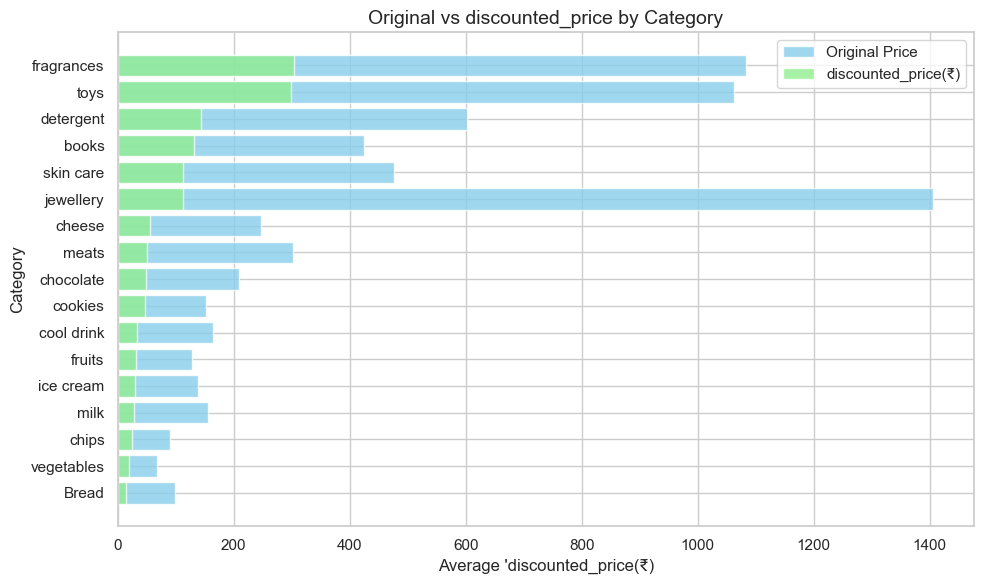

In [53]:
price_compare = new_df.groupby('category')[['original_price',  'discounted_price']].mean().sort_values(by = 'discounted_price',ascending = True).reset_index()
plt.figure(figsize=(10,6))
plt.barh(price_compare['category'], price_compare['original_price'], 
         color='skyblue', label='Original Price', alpha=0.8)
plt.barh(price_compare['category'], price_compare['discounted_price'], 
         color='lightgreen', label='discounted_price(₹)', alpha=0.8)
plt.title("Original vs discounted_price by Category", fontsize=14)
plt.xlabel("Average 'discounted_price(₹)", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

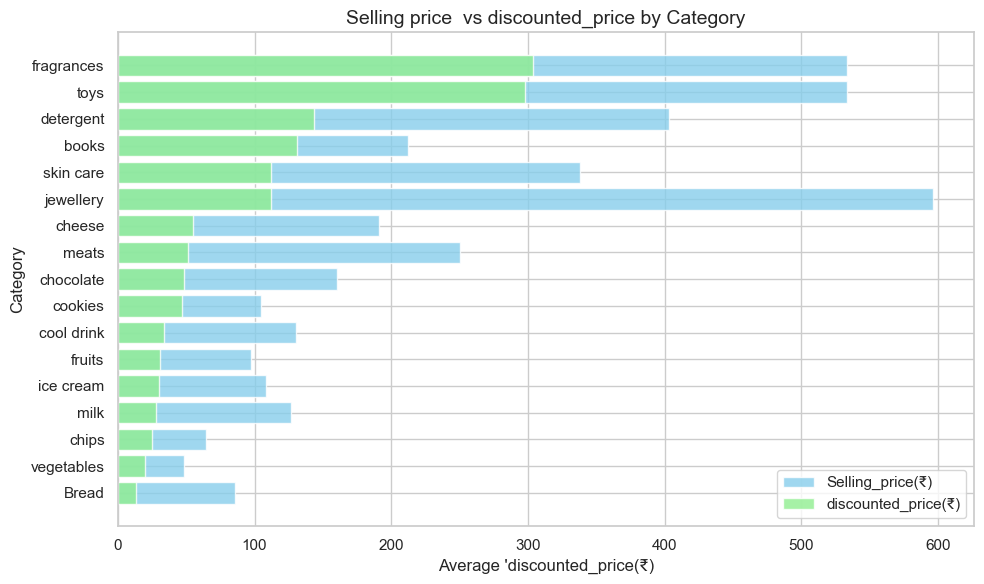

In [39]:
price_compare = new_df.groupby('category')[['discounted_price', 'Selling_price']].mean().sort_values(by = 'discounted_price',ascending = True).reset_index()
plt.figure(figsize=(10,6))
plt.barh(price_compare['category'], price_compare['Selling_price'], 
         color='skyblue', label='Selling_price(₹)', alpha=0.8)
plt.barh(price_compare['category'], price_compare['discounted_price'], 
         color='lightgreen', label='discounted_price(₹)', alpha=0.8)
plt.title("Selling price  vs discounted_price by Category", fontsize=14)
plt.xlabel("Average 'discounted_price(₹)", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### **Multivariate Analysis**

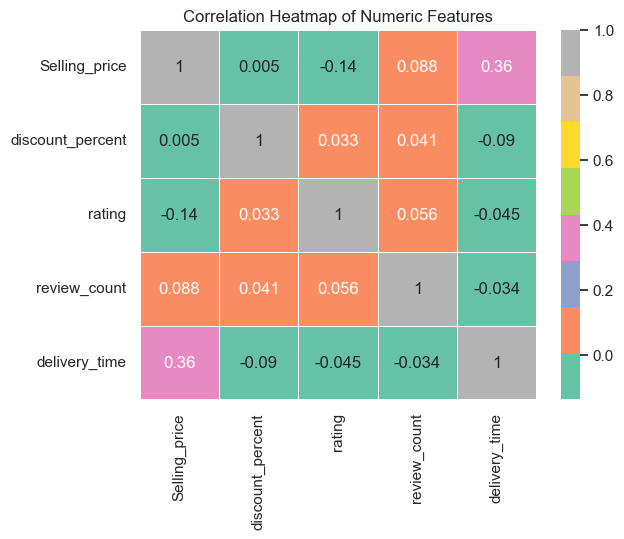

In [55]:
corr = new_df[['Selling_price', 'discount_percent', 'rating', 'review_count','delivery_time']].corr()
sns.heatmap(corr, annot=True, cmap='Set2', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.savefig("Correlation Heatmap of Numeric Features")
plt.show()

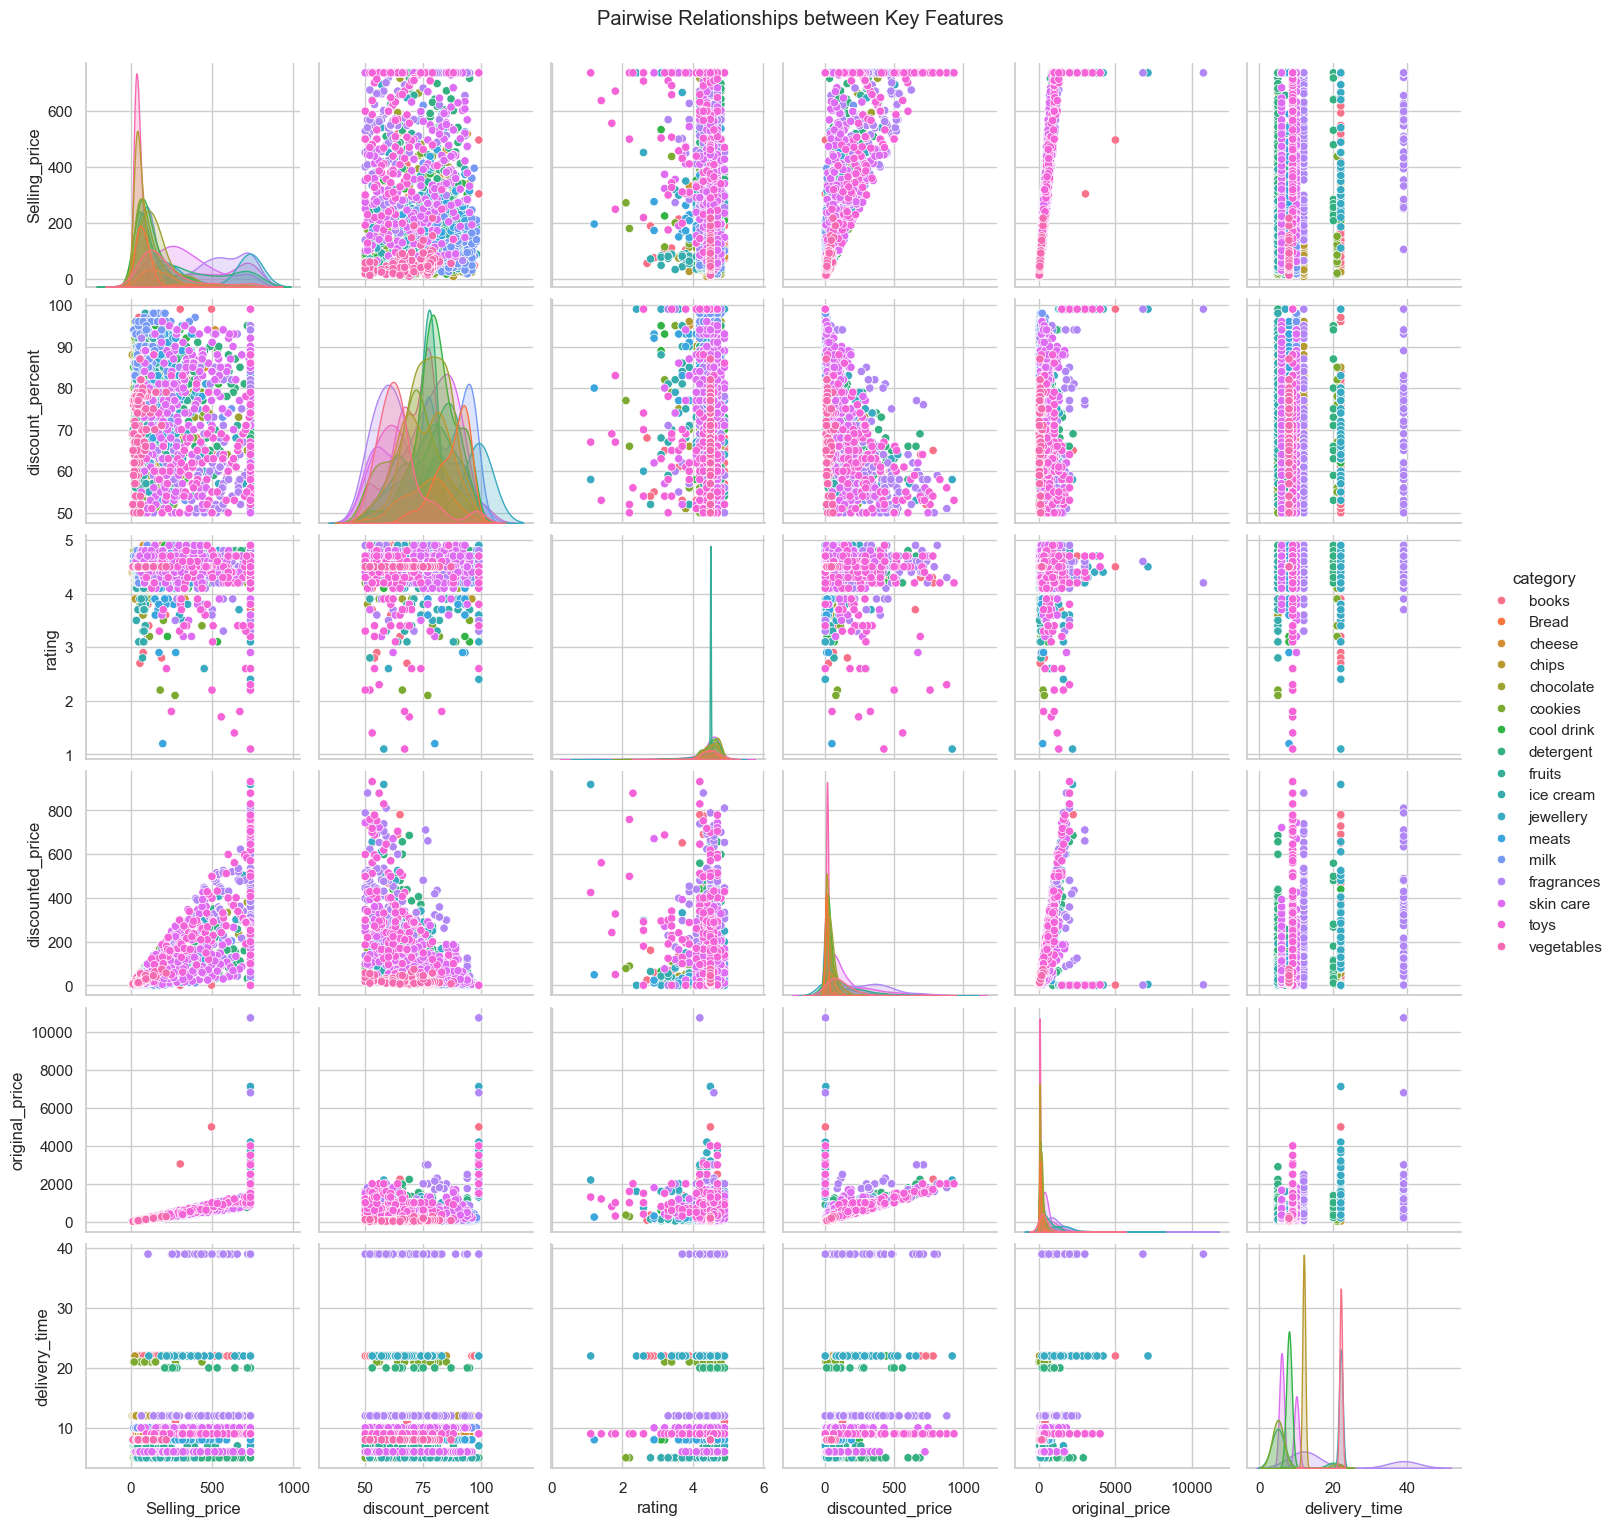

In [56]:
sns.pairplot(new_df, hue='category', vars=['Selling_price', 'discount_percent', 'rating','discounted_price','original_price','delivery_time'])
plt.suptitle('Pairwise Relationships between Key Features', y=1.02)
plt.show()

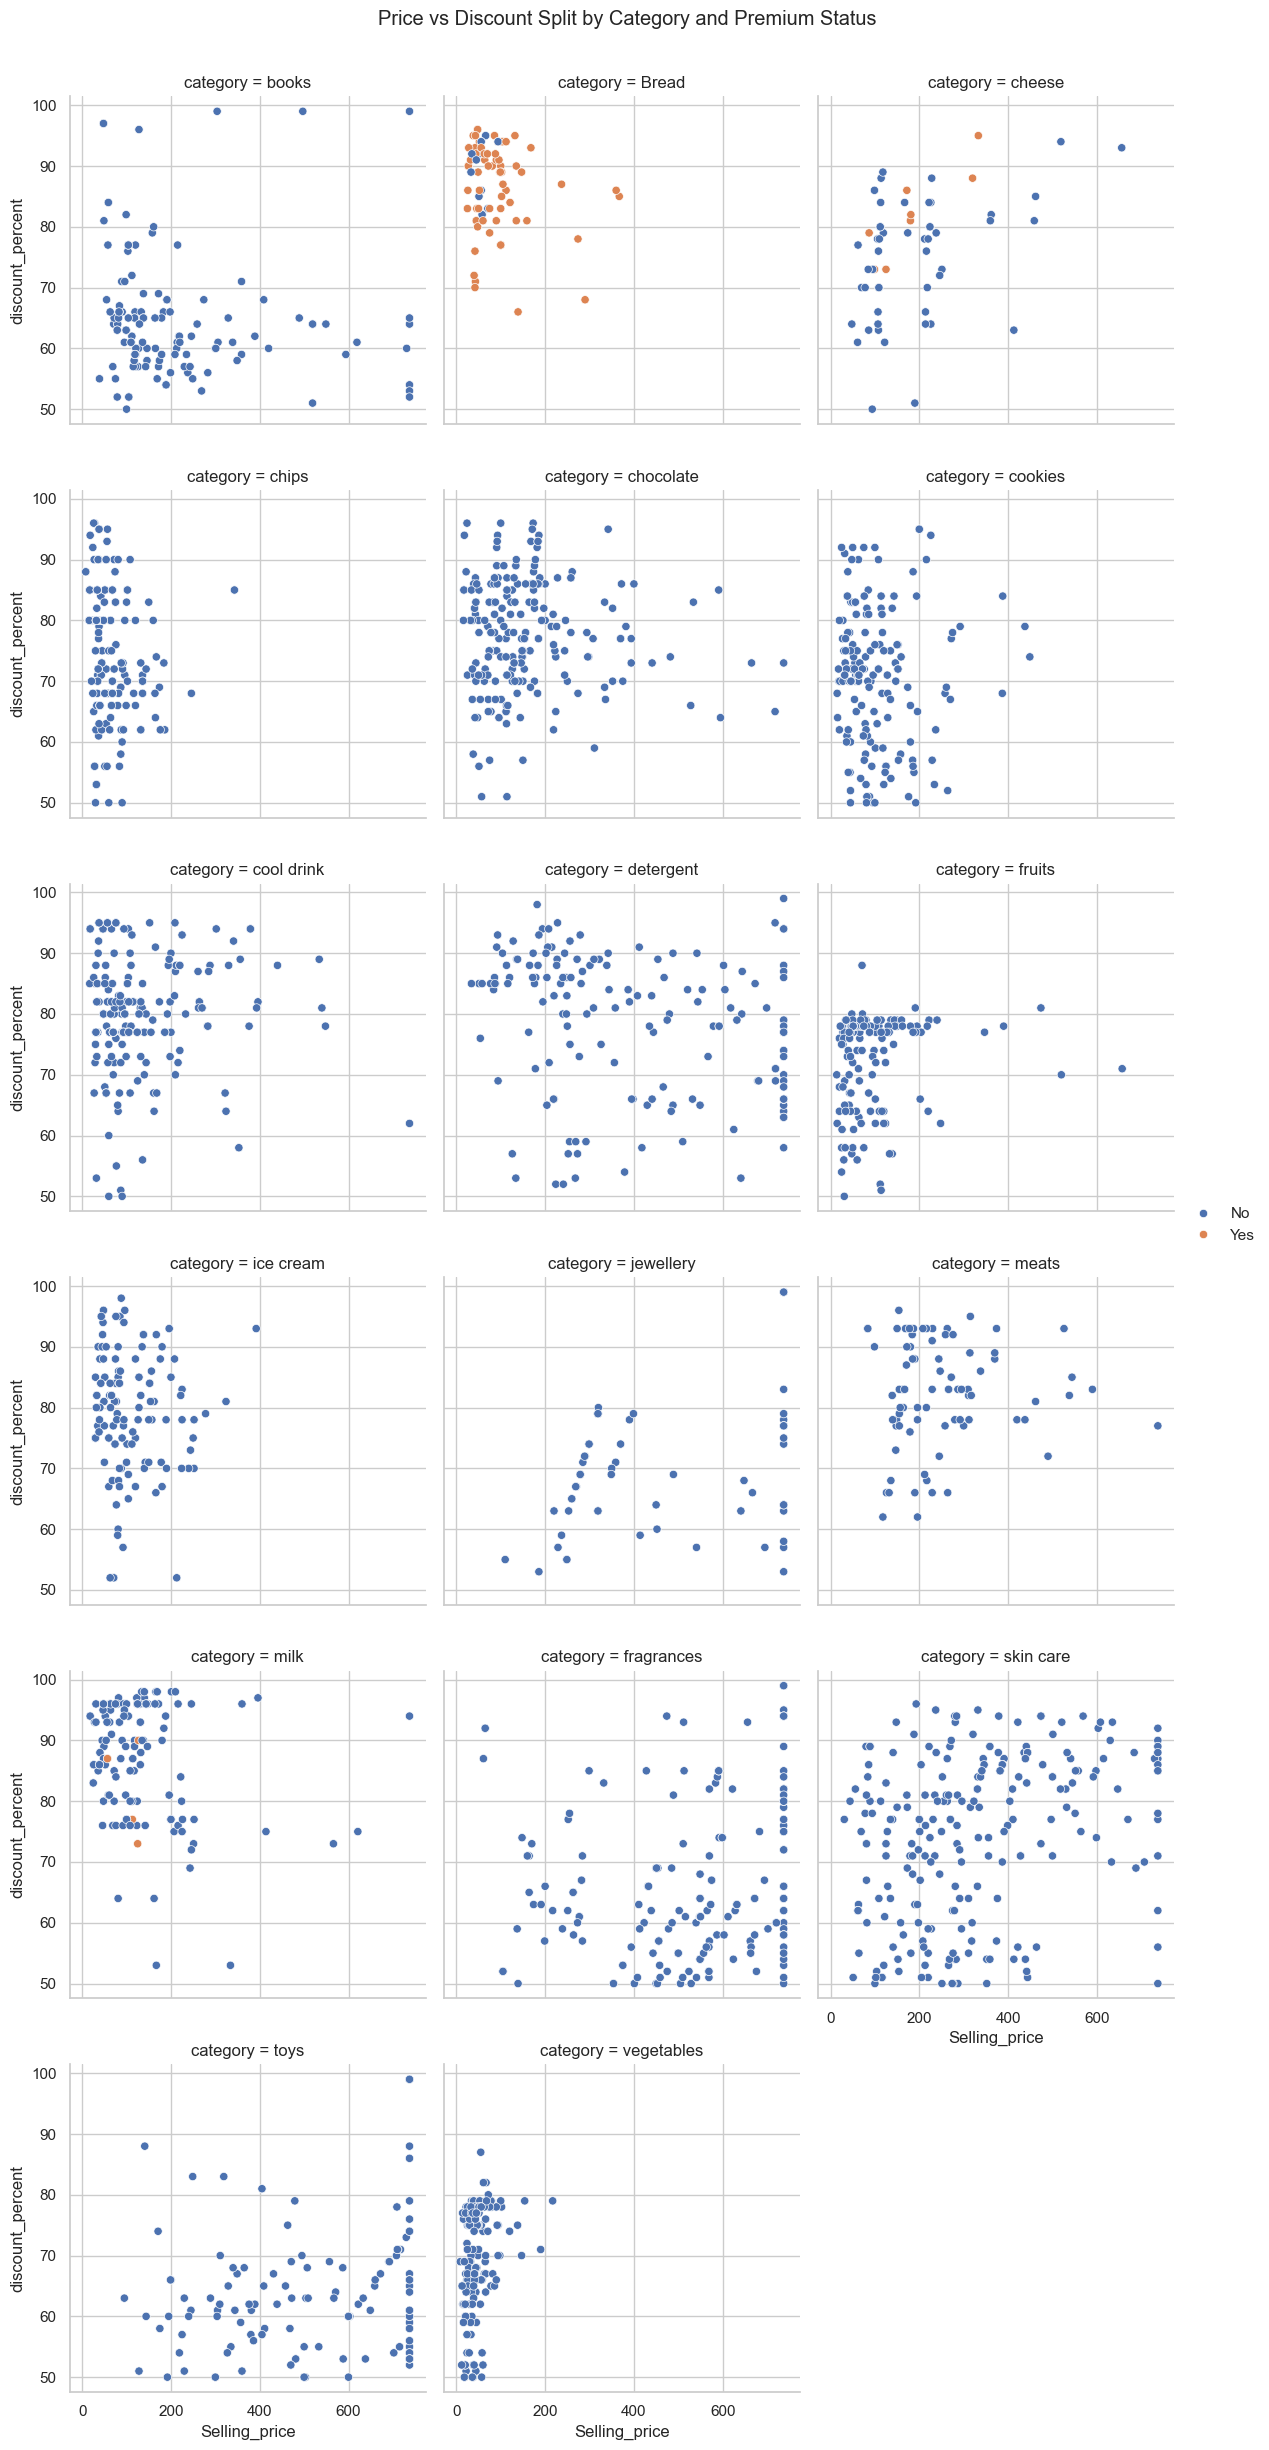

In [57]:
gride = sns.FacetGrid(new_df, col='category', col_wrap=3, height=4)
gride.map_dataframe(sns.scatterplot, x='Selling_price', y='discount_percent', hue='premium')
gride.add_legend()
plt.suptitle('Price vs Discount Split by Category and Premium Status', y=1.02)
plt.show()

### **Connecting Python Script to MySQL**


In [58]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


In [59]:
import mysql.connector
from mysql.connector import errorcode

try:
    conn = mysql.connector.connect(
        host="localhost",
        user="root",
        password="21r01a67g0",
        database="zepto_analysis"
    )
    cursor = conn.cursor()
    print("Connection successful")

except mysql.connector.Error as err:
    print("Error:", err)


Connection successful


In [60]:
try:
    insert_query = """
    INSERT INTO zepto_products (
        product_name,
        original_price,
        discounted_price,
        discount_percent,
        premium,
        quantity,
        rating,
        review_count,
        delivery_time,
        category,
        selling_price
    ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
    """

    data = [
        (
            row['product_name'],
            int(row['original_price']),
            int(row['discounted_price']),
            int(row['discount_percent']),
            row['premium'],
            row['quantity'],
            float(row['rating']),
            int(row['review_count']),
            int(row['delivery_time']),
            row['category'],
            int(row['selling_price'])
        )
        for index, row in df.iterrows()
    ]

    cursor.executemany(insert_query, data)
    conn.commit()
    print("Data inserted successfully")

except mysql.connector.Error as err:
    print("Error:", err)


Data inserted successfully


In [61]:
cursor.execute("SELECT * FROM zepto_products LIMIT 10;")
rows = cursor.fetchall()

for row in rows:
    print(row)


(1, 'My First Activity Book Word Search', 129, 1, 96, 'No', '1 pcs', Decimal('4.5'), 67, 22, 'books', 128)
(2, '2000+ Reward Stickers Book', 220, 94, 57, 'No', '2 pcs', Decimal('4.9'), 78, 22, 'books', 126)
(3, 'My First Book Of Writing Numbers ', 60, 11, 81, 'No', '1 pcs', Decimal('4.5'), 945, 22, 'books', 49)
(4, 'The Adventures of Sherlock Holmes', 499, 216, 56, 'No', '2 pcs', Decimal('4.4'), 170, 22, 'books', 283)
(5, 'Science Books For Kids', 180, 61, 66, 'No', '1 pcs', Decimal('4.5'), 71, 22, 'books', 119)
(6, 'My First Big Picture Board Book Abc', 120, 21, 82, 'No', '2 pcs', Decimal('4.7'), 68, 22, 'books', 99)
(7, 'Kids Encyclopedia', 155, 60, 61, 'No', '2 pcs', Decimal('4.8'), 82, 22, 'books', 95)
(8, 'Shlokas and Mantras and Hanuman Chalisa for Kids Age 2+', 110, 39, 64, 'No', '2 pcs', Decimal('4.6'), 88, 22, 'books', 71)
(9, 'My First Sticker Book', 135, 60, 55, 'No', '1 pcs', Decimal('2.9'), 82, 22, 'books', 75)
(10, 'My First 1000 Words Book L 50 Topics With Engaging Pictu

In [62]:
cursor.close()
conn.close()
